In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image
import os
from sklearn import preprocessing
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
# CONFIG
DATASET_PATH = "/data/dev/projects/ai/Trackey/trackey/research/HMDB51"
DATASET_FEATURES_PATH = "/data/dev/projects/ai/Trackey/trackey/research/EXTRACTED_HMDB51_FEATURES"
SEQ_FEATURE_MAP_CSV_PATH = "/data/dev/projects/ai/Trackey/trackey/research/SEQ_TO_FEATURES.csv"
MEDIAPIPE_FEATURE_SIZE = 132
SEQ_LEN = 60
NUM_CLASSES = 51

In [3]:
pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', None)       # Auto-detect width

In [4]:
def load_data_to_dataframe(path):
    rows = []
    for activity in tqdm(list(os.scandir(path)), desc="Activities"):
        if not activity.is_dir():
            continue
        for seq in os.scandir(activity.path):
            if not seq.is_dir():
                continue
            frame_count = sum(1 for _ in os.scandir(seq.path))
            rows.append({
                "activity_seq_name": seq.name,
                "activity_seq_path": seq.path,
                "activity_seq_length": frame_count,
                "activity": activity.name
            })
    df = pd.DataFrame(rows)
    return df
df = load_data_to_dataframe(DATASET_PATH)
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Activities: 100%|█████████████████████████████| 51/51 [00:00<00:00, 791.22it/s]


Using cuda device


In [5]:
df.head()

,activity_seq_name,activity_seq_path,activity_seq_length,activity
0,SE7EN_SMILES_x3_smile_h_cm_np1_fr_med_3,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
1,smile_collection_7_smile_h_nm_np1_fr_goo_0,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
2,SE7EN_SMILES_x3_smile_h_nm_np1_fr_med_8,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
3,YouTube_smiles!_smile_h_cm_np1_fr_bad_37,/data/dev/projects/ai/Trackey/trackey/research...,13,smile
4,Re-_Show_your_Smile!_10_smile_h_nm_np1_fr_goo_0,/data/dev/projects/ai/Trackey/trackey/research...,16,smile


In [6]:
df['activity'].unique()

<StringArray>
[         'smile',           'golf',     'somersault',    'shake_hands',
           'talk',          'throw',   'climb_stairs', 'swing_baseball',
      'handstand',            'hug',         'pushup',     'brush_hair',
           'chew',          'sword',            'sit',           'kick',
      'shoot_bow',           'pour',           'kiss',     'fall_floor',
           'wave',          'catch',           'turn',     'ride_horse',
        'fencing',          'climb',      'ride_bike',           'pick',
      'kick_ball', 'sword_exercise',          'laugh',          'drink',
         'pullup',          'stand',           'walk',          'situp',
            'eat',      'flic_flac',           'clap',     'draw_sword',
           'jump',            'run',        'dribble',            'hit',
          'punch',     'shoot_ball',          'smoke',      'shoot_gun',
           'push',           'dive',      'cartwheel']
Length: 51, dtype: str

In [7]:
len(df['activity'].unique())

51

In [8]:
def encode_catagorical_data(df, target_col='activity'):
    enc = preprocessing.OneHotEncoder()
    enc.fit(np.array(df[target_col]).reshape(-1,1))
    return enc.transform(np.array(df[target_col]).reshape(-1,1))
encode_catagorical_data(df)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6766 stored elements and shape (6766, 51)>

In [9]:
len(df)

6766

In [10]:
df.head()

,activity_seq_name,activity_seq_path,activity_seq_length,activity
0,SE7EN_SMILES_x3_smile_h_cm_np1_fr_med_3,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
1,smile_collection_7_smile_h_nm_np1_fr_goo_0,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
2,SE7EN_SMILES_x3_smile_h_nm_np1_fr_med_8,/data/dev/projects/ai/Trackey/trackey/research...,16,smile
3,YouTube_smiles!_smile_h_cm_np1_fr_bad_37,/data/dev/projects/ai/Trackey/trackey/research...,13,smile
4,Re-_Show_your_Smile!_10_smile_h_nm_np1_fr_goo_0,/data/dev/projects/ai/Trackey/trackey/research...,16,smile


In [11]:
df.to_csv("HMDB51_Metadata.csv", index=False)

In [12]:
max(df["activity_seq_length"])

213

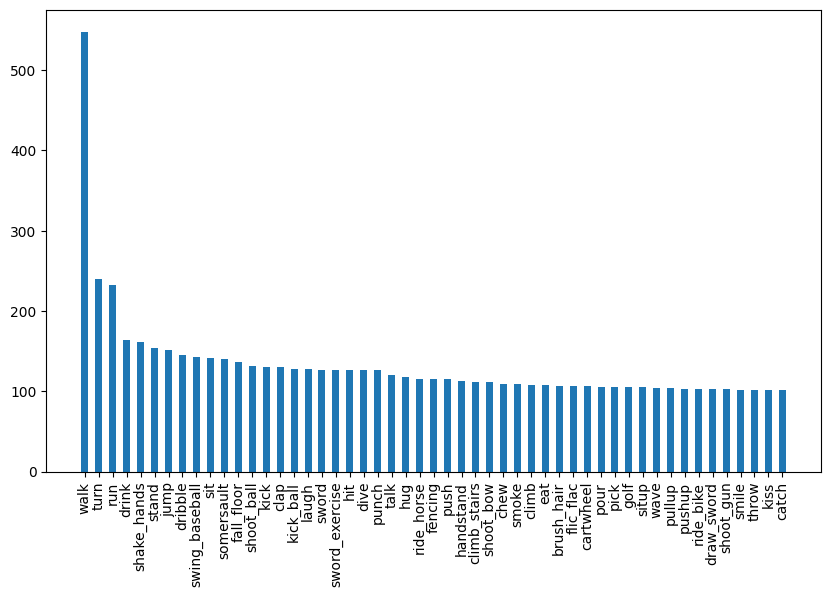

In [13]:
def plot_activity_histogram(df, activity_col = 'activity'):
    # print(df[activity_col].value_counts())
    # df[activity_col].value_counts().plot(kind='bar', xlabel='Activity', ylabel='Count', rot=0)
    plt.figure(figsize=(10, 6))
    plt.bar(df[activity_col].value_counts().keys(), height=df[activity_col].value_counts(), width=0.5)
    plt.xticks(rotation='vertical')
    plt.show()
plot_activity_histogram(df)

In [14]:
path = df.loc[0]["activity_seq_path"]
np.array(Image.open(f"{path}/10000.jpg")).shape

(240, 320, 3)

In [15]:
def load_sequence(sequence_path) -> np.ndarray:
    """
    Load a single sequence in shape (t, h, w, c)
    """
    frames = []

    for image in sorted(os.listdir(sequence_path)):
        img = np.array(Image.open(os.path.join(sequence_path, image)))
        frames.append(img)

    return np.stack(frames, axis=0)
%timeit load_sequence(df.loc[0]["activity_seq_path"])

7.7 ms ± 294 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
seq = load_sequence(df.loc[0]["activity_seq_path"])
seq.shape

(16, 240, 320, 3)

In [17]:
# !wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

In [18]:
class FeatureExtractor:
    def __init__(self):
        import mediapipe as mp
        from mediapipe.tasks import python
        from mediapipe.tasks.python import vision

        base_options = python.BaseOptions(
            model_asset_path='pose_landmarker.task'
        )

        options = vision.PoseLandmarkerOptions(
            base_options=base_options
        )

        self.detector = vision.PoseLandmarker.create_from_options(options)
        self.mp = mp

        self.NUM_LANDMARKS = 33   # Mediapipe pose standard

    def extract(self, img_path):
        image = self.mp.Image.create_from_file(img_path)
        result = self.detector.detect(image)

        features = []

        # If detection failed → return full zero vector
        if not result.pose_landmarks:
            return torch.zeros(self.NUM_LANDMARKS * 4)

        landmarks = result.pose_landmarks[0]

        # Force fixed landmark ordering
        for i in range(self.NUM_LANDMARKS):
            if i < len(landmarks):
                lm = landmarks[i]
                features.extend([lm.x, lm.y, lm.z, lm.visibility])
            else:
                # Pad missing landmarks
                features.extend([0.0, 0.0, 0.0, 0.0])

        return torch.tensor(features, dtype=torch.float32)

In [19]:
def process_sequence_folder(seq_folder, extractor):
    frames = []

    for frame_name in sorted(os.listdir(seq_folder)):
        frame_path = os.path.join(seq_folder, frame_name)
        features = extractor.extract(frame_path)
        frames.append(features)

    return torch.stack(frames)  # (seq_len, 132)

In [20]:
def save_sequence_tensor(seq_tensor, save_path):
    torch.save(seq_tensor, save_path)

In [21]:
def pad_or_trim(sequence, seq_len=30):
    seq_len_current, feat_dim = sequence.shape

    if seq_len_current > seq_len:
        return sequence[:seq_len]

    if seq_len_current < seq_len:
        padding = torch.zeros(
            seq_len - seq_len_current,
            feat_dim,
            device=sequence.device
        )
        return torch.cat([sequence, padding], dim=0)

    return sequence

In [22]:
def process_dataset(root_dataset_path, output_dir, csv_output_path):
    os.makedirs(output_dir, exist_ok=True)

    extractor = FeatureExtractor()
    data_rows = []

    label_to_index = {}
    current_label_index = 0

    for action_folder in sorted(os.listdir(root_dataset_path)):
        action_path = os.path.join(root_dataset_path, action_folder)

        if not os.path.isdir(action_path):
            continue

        # Create numeric label
        if action_folder not in label_to_index:
            label_to_index[action_folder] = current_label_index
            current_label_index += 1

        label_index = label_to_index[action_folder]

        for seq_folder in sorted(os.listdir(action_path)):
            seq_path = os.path.join(action_path, seq_folder)

            if not os.path.isdir(seq_path):
                continue

            print("Processing:", seq_path)

            seq_tensor = process_sequence_folder(seq_path, extractor)
            seq_tensor = pad_or_trim(seq_tensor, SEQ_LEN)

            save_name = f"{action_folder}_{seq_folder}.pt"
            save_path = os.path.join(output_dir, save_name)

            torch.save(seq_tensor, save_path)

            # Add row for CSV
            data_rows.append({
                "pt_path": save_path,
                "label_name": action_folder,
                "label_index": label_index
            })

    # Save CSV
    df = pd.DataFrame(data_rows)
    df.to_csv(csv_output_path, index=False)

    print("CSV saved to:", csv_output_path)
    print("Label mapping:", label_to_index)

In [23]:
process_dataset(DATASET_PATH, DATASET_FEATURES_PATH, SEQ_FEATURE_MAP_CSV_PATH)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772886274.643630   25339 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772886274.698247   25339 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772886274.759690   25344 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_0
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_1
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_2
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np1_ba_goo_4
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np1_ri_med_3
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np2_le_goo_0
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np2_le_goo_1
Processing: /data/dev/projects/ai/Trackey/trackey/research/HMDB51/brush_hair/Aussie_Brunette_Brushi

In [24]:
torch.load("/data/dev/projects/ai/Trackey/trackey/research/EXTRACTED_HMDB51_FEATURES/brush_hair_April_09_brush_hair_u_nm_np1_ba_goo_0.pt").shape

torch.Size([60, 132])

In [25]:
seq_metadata = pd.read_csv(SEQ_FEATURE_MAP_CSV_PATH)
seq_metadata.head()

,pt_path,label_name,label_index
0,/data/dev/projects/ai/Trackey/trackey/research...,brush_hair,0
1,/data/dev/projects/ai/Trackey/trackey/research...,brush_hair,0
2,/data/dev/projects/ai/Trackey/trackey/research...,brush_hair,0
3,/data/dev/projects/ai/Trackey/trackey/research...,brush_hair,0
4,/data/dev/projects/ai/Trackey/trackey/research...,brush_hair,0


In [26]:
seq_metadata[seq_metadata['label_name'].isin(["hug", "kick"])]

,pt_path,label_name,label_index
2126,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2127,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2128,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2129,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2130,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2131,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2132,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2133,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2134,/data/dev/projects/ai/Trackey/trackey/research...,hug,18
2135,/data/dev/projects/ai/Trackey/trackey/research...,hug,18


In [27]:
os.path.join(df.loc[0]["activity_seq_path"], os.listdir(df.loc[0]["activity_seq_path"])[0])

'/data/dev/projects/ai/Trackey/trackey/research/HMDB51/smile/SE7EN_SMILES_x3_smile_h_cm_np1_fr_med_3/10004.jpg'

In [28]:
extractor = FeatureExtractor()
result = extractor.extract(os.path.join(df.loc[0]["activity_seq_path"], os.listdir(df.loc[0]["activity_seq_path"])[0]))

len(result)

W0000 00:00:1772892014.955200   40414 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772892015.005832   40414 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


132

In [29]:
class CustomSequenceDataset(Dataset):
    def __init__(self, dataset_metadata_csv_path, seq_paths_col = 'activity_seq_path',
                 target_labels_col = 'activity', labels_string_col = 'activity',
                 transform=None, target_transform=None, load_extracted_features = True, train_on_labels=None):
        self.dataset = pd.read_csv(dataset_metadata_csv_path)
        self.transform = transform
        self.target_transform = target_transform
        self.load_extracted_features = load_extracted_features
        if train_on_labels:
            if not isinstance(train_on_labels, list):
                raise Exception("train_on_labels must be a list of strings of labels to train on.")
            
            self.dataset = self.dataset[self.dataset[labels_string_col].isin(train_on_labels)]
        self.dataset = self.dataset.reset_index(drop=True)
        self.seq_labels = self.dataset[target_labels_col]
        self.seq_paths = self.dataset[seq_paths_col]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        seq_path = self.seq_paths.iloc[idx]
        # print("seq_path : ", seq_path)
        label = self.seq_labels.iloc[idx]
        # print("label : ", label)
        if self.load_extracted_features:
            seq = self.load_pt(seq_path)
        else:
            seq = self.load_sequence(seq_path)
        if self.target_transform:
            label = self.target_transform(label)
        return seq, label

    def load_sequence(self, sequence_path) -> np.ndarray:
        """
        Load a single sequence in shape (t, h, w, c)
        """
        frames = []
    
        for frame_path in sorted(os.listdir(sequence_path)):
            if self.load_image_in_transform:
                frame = self.transform(os.path.join(sequence_path, frame_path))
            else:
                frame = decode_image(os.path.join(sequence_path, frame_path))
                if self.transform:
                    frame = self.transform(frame)
            frames.append(frame)
    
        return torch.stack(frames)

    def load_pt(self, pt_path):
        return torch.load(pt_path)

In [30]:
# ds = CustomSequenceDataset("SEQ_TO_FEATURES.csv", seq_paths_col = "pt_path",
#                            target_labels_col = "label_index", labels_string_col = "label_name",load_extracted_features = True)

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
device = "cpu"

In [33]:
# ds.__getitem__(0)[0].shape

In [34]:
class RecurrentModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.gru = nn.GRU(
            input_size=MEDIAPIPE_FEATURE_SIZE,
            hidden_size=128,
            num_layers=4,
            batch_first=True,
            dropout=0.25
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 224),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(224, 224),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(224, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, feature_size)

        out, h_n = self.gru(x)

        # Take last time step
        out = out[:, -1, :]   # (batch, hidden_size)

        logits = self.fc(out)
        return logits

model = RecurrentModel().to(device)
print(model)

RecurrentModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (gru): GRU(132, 128, num_layers=4, batch_first=True, dropout=0.25)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=224, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=224, out_features=224, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=224, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=51, bias=True)
  )
)


In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [36]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    epoch_loss=0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss, current = loss.item(), (batch + 1) * len(X)
        epoch_loss+=loss

        if batch % 100 == 0:
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return (epoch_loss / num_batches)

In [37]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, 100*correct

In [38]:
dataset = CustomSequenceDataset("SEQ_TO_FEATURES.csv", 
                                seq_paths_col="pt_path",
                                target_labels_col="label_index",
                                labels_string_col="label_name",
                                load_extracted_features=True)

In [39]:
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.15,
    stratify=dataset.seq_labels,
    random_state=42
)
len(train_indices)

5751

In [40]:
len(val_indices)

1015

In [41]:
train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)

In [42]:
len(train_dataloader)

180

In [43]:
epochs = 100
train_history = []
val_history = []
val_accuracy_history = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    epoch_loss = train(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_accuracy = test(val_dataloader, model, loss_fn)
    train_history.append(epoch_loss)
    val_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)
print("Done!")

Epoch 1
-------------------------------
loss: 3.926262  [   32/ 5751]
loss: 3.813004  [ 3232/ 5751]
Test Error: 
 Accuracy: 8.8%, Avg loss: 3.612767 

Epoch 2
-------------------------------
loss: 3.660514  [   32/ 5751]
loss: 3.514715  [ 3232/ 5751]
Test Error: 
 Accuracy: 10.0%, Avg loss: 3.511014 

Epoch 3
-------------------------------
loss: 3.215468  [   32/ 5751]
loss: 3.193599  [ 3232/ 5751]
Test Error: 
 Accuracy: 8.8%, Avg loss: 3.557259 

Epoch 4
-------------------------------
loss: 3.608502  [   32/ 5751]
loss: 3.341199  [ 3232/ 5751]
Test Error: 
 Accuracy: 10.5%, Avg loss: 3.407860 

Epoch 5
-------------------------------
loss: 3.349653  [   32/ 5751]
loss: 3.719173  [ 3232/ 5751]
Test Error: 
 Accuracy: 9.5%, Avg loss: 3.415663 

Epoch 6
-------------------------------
loss: 3.341103  [   32/ 5751]
loss: 3.425887  [ 3232/ 5751]
Test Error: 
 Accuracy: 11.6%, Avg loss: 3.337451 

Epoch 7
-------------------------------
loss: 3.193061  [   32/ 5751]
loss: 3.065536  [ 323

In [44]:
val_history

[3.6127674877643585,
 3.511014461517334,
 3.5572593212127686,
 3.4078604504466057,
 3.4156633839011192,
 3.337451383471489,
 3.371553882956505,
 3.1226367577910423,
 3.1727680414915085,
 3.166462354362011,
 3.0825948864221573,
 3.0119951143860817,
 2.9742787703871727,
 3.0035299584269524,
 2.9677560180425644,
 2.925783082842827,
 2.905397690832615,
 2.851442962884903,
 2.8513112664222717,
 2.948728658258915,
 2.875364027917385,
 2.8218340054154396,
 2.9137918949127197,
 2.8806342482566833,
 2.8121659457683563,
 2.8492783084511757,
 2.761459518224001,
 2.758599169552326,
 2.725932963192463,
 2.647228054702282,
 2.6440241634845734,
 2.713191479444504,
 2.717342060059309,
 2.6256939209997654,
 2.67441963031888,
 2.831538811326027,
 2.698291100561619,
 2.694108821451664,
 2.658550728112459,
 2.712119158357382,
 2.6589832827448845,
 2.719892680644989,
 2.655009489506483,
 2.784451760351658,
 2.9086456298828125,
 2.8021376840770245,
 2.823992319405079,
 2.863986872136593,
 2.8495824187994003

In [45]:
val_accuracy_history

[8.768472906403941,
 9.950738916256158,
 8.768472906403941,
 10.541871921182267,
 9.458128078817735,
 11.625615763546799,
 12.11822660098522,
 14.088669950738916,
 13.694581280788176,
 15.566502463054189,
 16.551724137931036,
 17.04433497536946,
 17.339901477832512,
 17.536945812807883,
 19.113300492610836,
 19.113300492610836,
 20.39408866995074,
 21.2807881773399,
 20.39408866995074,
 21.083743842364534,
 21.379310344827587,
 24.039408866995075,
 21.083743842364534,
 23.54679802955665,
 21.87192118226601,
 23.054187192118228,
 25.02463054187192,
 24.334975369458128,
 28.078817733990146,
 28.669950738916256,
 30.640394088669954,
 28.768472906403943,
 27.980295566502463,
 28.866995073891626,
 28.27586206896552,
 29.655172413793103,
 29.55665024630542,
 29.95073891625616,
 30.147783251231523,
 29.261083743842363,
 31.03448275862069,
 32.01970443349754,
 29.95073891625616,
 30.738916256157633,
 29.852216748768473,
 30.443349753694584,
 29.95073891625616,
 29.852216748768473,
 31.62561576

In [46]:
train_history

[3.806527316570282,
 3.55052012734943,
 3.5041260533862646,
 3.467985236644745,
 3.435237611664666,
 3.348351840178172,
 3.2923470748795403,
 3.199690267774794,
 3.149017161793179,
 3.0959956301583182,
 3.073221480846405,
 3.0182799922095405,
 2.990958160824246,
 2.9406432032585146,
 2.9059318317307365,
 2.8572609941164653,
 2.84162075387107,
 2.8106384529007804,
 2.770512545108795,
 2.717487425274319,
 2.6974154988924663,
 2.647141542037328,
 2.6210024270746444,
 2.571132711569468,
 2.549670839971966,
 2.52811514933904,
 2.5182450705104404,
 2.460964110824797,
 2.4203509959909653,
 2.3710622270901998,
 2.3604819085862903,
 2.3131204466025035,
 2.2980428304937153,
 2.2510595507091944,
 2.2279645959536234,
 2.2138934055964152,
 2.2181868142551844,
 2.175242194864485,
 2.1346345206101733,
 2.115768665737576,
 2.094435245460934,
 2.0486451658937668,
 2.036230640278922,
 2.01314598719279,
 1.99713803463512,
 1.9846566299597421,
 1.9482807927661472,
 1.902579019467036,
 1.91595010360082,
 1

In [47]:
np.arange(len(train_history))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

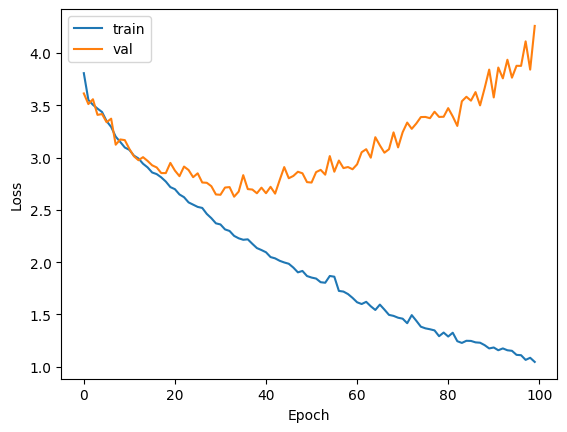

In [48]:
plt.plot(train_history, label='train')
plt.plot(val_history, label='val')
plt.xlabel("Epoch")
plt.ylabel("Loss")   # or Accuracy depending on what you're plotting
plt.legend()
plt.show()